C:\Dev\Tools\Miniconda3\envs\cafe\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading xGATE Network Data...

Loading Single-Cell Data...


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen


Extracting covariance-based PCA embeddings (sqrt(lambda_1) * v_1)...

xGATE CH Index: 6.02
Gene Expression CH Index: 0.90

Running UMAP Reductions...


C:\Dev\Tools\Miniconda3\envs\cafe\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


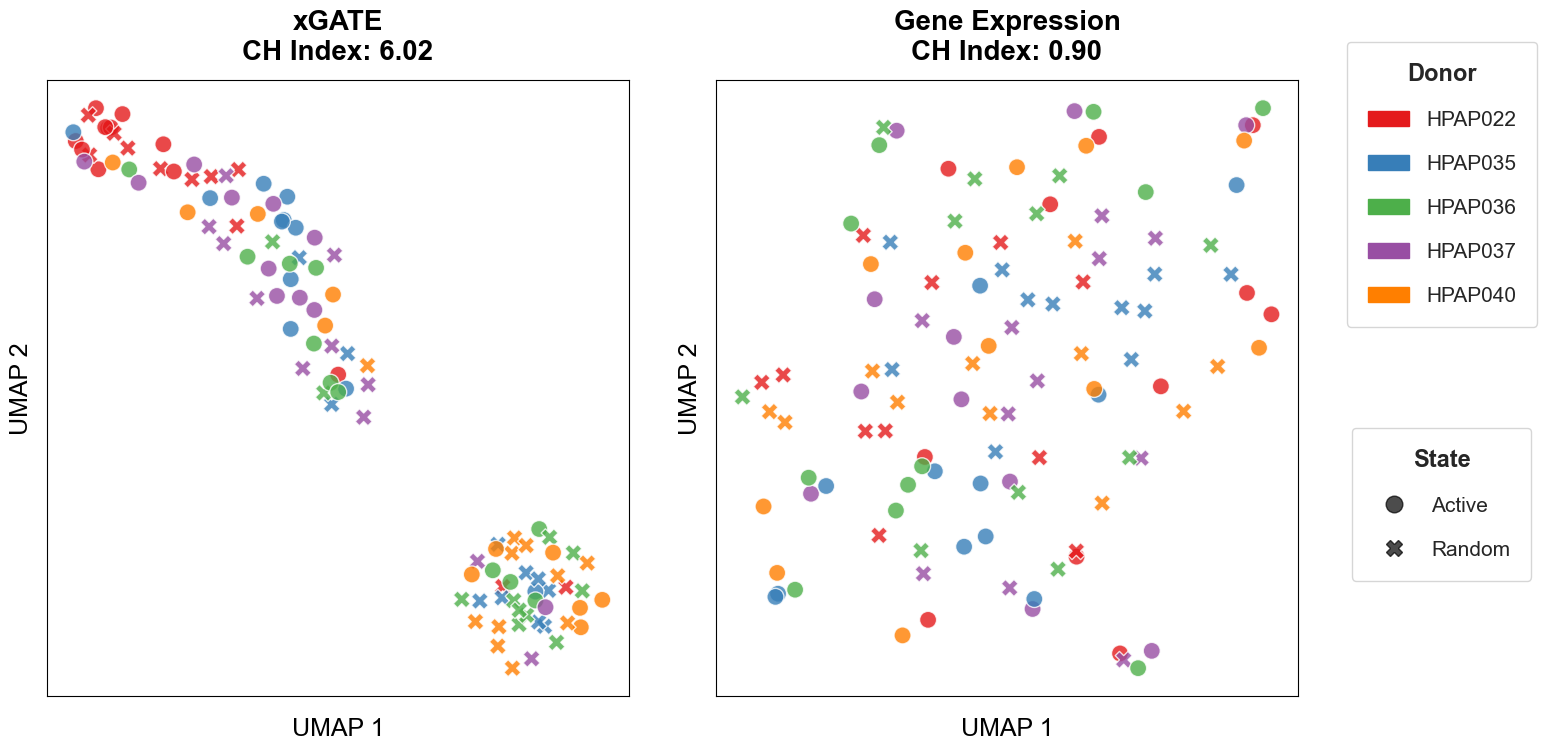

In [1]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import scanpy as sc
import mygene
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from sklearn.metrics import calinski_harabasz_score

# Import your local utilities
from utilities_seeded import get_categorized_pathways, gather_pathways_between, get_genes_in_pathway

# Set seeds for complete reproducibility
random.seed(42)
np.random.seed(42)

# ==============================================================================
# 1. LOAD AND FORMAT xGATE NETWORK DATA (FROM .PKL)
# ==============================================================================
print("Loading xGATE Network Data...")
current_dir = os.getcwd()
load_path = os.path.join(current_dir, "data", "all_embedding_data.pkl")

with open(load_path, 'rb') as f:
    all_embedding_data = pickle.load(f)

# Find global k for network embeddings (using the //3 rule mentioned)
all_lengths = [len(data['pathway_embedding']) 
               for donor in all_embedding_data.values() 
               for data in donor.values()]
k_net = min(all_lengths) // 3

X_list_net, net_labels, net_donors = [], [], []

for donor_id, pathways in all_embedding_data.items():
    for path_name, data in pathways.items():
        # Active
        X_list_net.append(np.array(data['pathway_embedding']).flatten()[:k_net])
        net_labels.append("Active")
        net_donors.append(donor_id)
        
        # Inactive (1 random null)
        null_emb = random.choice(data['null_embeddings'])
        X_list_net.append(np.array(null_emb).flatten()[:k_net])
        net_labels.append("Inactive")
        net_donors.append(donor_id)

X_net = np.array(X_list_net)
net_labels = np.array(net_labels)
net_donors = np.array(net_donors)

# ==============================================================================
# 2. LOAD AND FORMAT SINGLE-CELL DATA (FROM .H5AD)
# ==============================================================================
print("\nLoading Single-Cell Data...")
pancreas_path = os.path.join(current_dir, "data", "pancreas_human.h5ad")
pancreas_data = sc.read(pancreas_path)

filtered_data = pancreas_data[
    (pancreas_data.obs['cell_type'] == 'type B pancreatic cell') &
    (pancreas_data.obs['disease_state'] == 'Control')
].copy()

cell_counts = filtered_data.obs['donor_id'].value_counts()
donors_to_keep = cell_counts[cell_counts >= 200].index
filtered_data = filtered_data[filtered_data.obs['donor_id'].isin(donors_to_keep)].copy()

X_full = filtered_data.X
if not isinstance(X_full, np.ndarray):
    X_full = X_full.toarray()
    
all_sc_genes = sorted(filtered_data.var_names.tolist())
gene_to_idx = {gene: idx for idx, gene in enumerate(all_sc_genes)}

# --- Translate Genes ---
test_pathways = [
    "Autophagy", "Protein processing in endoplasmic reticulum", 
    "mTOR signaling pathway", "HIF-1 signaling pathway", 
    "AMPK signaling pathway", "PPAR signaling pathway", 
    "Protein digestion and absorption", "PI3K-Akt signaling pathway", 
    "Insulin signaling pathway", "Oxidative phosphorylation", 
    "cGMP-PKG signaling pathway"
]

categorized_pathways = get_categorized_pathways()
pathway_gene_dict = {}
mg = mygene.MyGeneInfo()

for pathway_name in test_pathways:
    pathway_list = gather_pathways_between(pathway_name, pathway_name, categorized_pathways)
    raw_genes = get_genes_in_pathway(pathway_list)
    if not raw_genes: continue
    
    entrez_ids = [g.replace('hsa:', '') for g in raw_genes]
    mg_results = mg.querymany(entrez_ids, scopes='entrezgene', fields='ensembl.gene', species='human', verbose=False)
    
    ensembl_ids = []
    for res in mg_results:
        if 'ensembl' in res:
            if isinstance(res['ensembl'], list): ensembl_ids.extend([e['gene'] for e in res['ensembl']])
            else: ensembl_ids.append(res['ensembl']['gene'])
                
    valid_genes = [g for g in ensembl_ids if g in gene_to_idx]
    if len(valid_genes) > 0:
        pathway_gene_dict[pathway_name] = sorted(list(set(valid_genes)))
k_sc = min(len(genes) for genes in pathway_gene_dict.values())

# --- Extract Covariance-PCA Embeddings ---
print("\nExtracting covariance-based PCA embeddings (sqrt(lambda_1) * v_1)...")
X_list_sc, sc_labels, sc_donors = [], [], []

for donor_id in donors_to_keep:
    donor_cell_idx = np.where(filtered_data.obs['donor_id'] == donor_id)[0]
    X_donor = X_full[donor_cell_idx, :]
    N_d = X_donor.shape[0]

    for pathway_name, active_genes in pathway_gene_dict.items():
        # --- A. ACTIVE REPRESENTATIVE VECTOR ---
        gs_col_idx = [gene_to_idx[g] for g in active_genes]
        X_subset = X_donor[:, gs_col_idx]

        # Center and compute sample covariance
        mu_dk = np.mean(X_subset, axis=0)
        X_centered = X_subset - mu_dk
        Sigma_dk = (X_centered.T @ X_centered) / (N_d - 1)

        # PCA via eigendecomposition
        eigvals, eigvecs = np.linalg.eigh(Sigma_dk)
        idx_max = np.argmax(eigvals)
        lambda_1 = max(eigvals[idx_max], 0.0) # Numerical guard
        v_1 = eigvecs[:, idx_max]

        # Truncate sigma_1 * v_1 to global min dimension k_sc
        emb_active = (np.sqrt(lambda_1) * v_1)[:k_sc]
        X_list_sc.append(emb_active)
        sc_labels.append("Active")
        sc_donors.append(donor_id)

        # --- B. INACTIVE REPRESENTATIVE VECTOR ---
        inactive_genes = random.sample(all_sc_genes, len(active_genes))
        gs_col_idx_null = [gene_to_idx[g] for g in inactive_genes]
        X_subset_null = X_donor[:, gs_col_idx_null]

        mu_null = np.mean(X_subset_null, axis=0)
        X_centered_null = X_subset_null - mu_null
        Sigma_null = (X_centered_null.T @ X_centered_null) / (N_d - 1)
        
        eigvals_null, eigvecs_null = np.linalg.eigh(Sigma_null)
        idx_max_null = np.argmax(eigvals_null)
        lambda_1_null = max(eigvals_null[idx_max_null], 0.0)
        v_1_null = eigvecs_null[:, idx_max_null]

        emb_null = (np.sqrt(lambda_1_null) * v_1_null)[:k_sc]
        X_list_sc.append(emb_null)
        sc_labels.append("Inactive")
        sc_donors.append(donor_id)

X_sc = np.array(X_list_sc)
sc_labels = np.array(sc_labels)
sc_donors = np.array(sc_donors)

# ==============================================================================
# 3. CH SCORES AND UMAP REDUCTION
# ==============================================================================
ch_net = calinski_harabasz_score(X_net, net_labels)
ch_sc = calinski_harabasz_score(X_sc, sc_labels)

print(f"\nxGATE CH Index: {ch_net:.2f}")
print(f"Gene Expression CH Index: {ch_sc:.2f}")

print("\nRunning UMAP Reductions...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
u_net_2d = reducer.fit_transform(X_net)
u_sc_2d = reducer.fit_transform(X_sc)

# ==============================================================================
# 4. FINAL SIDE-BY-SIDE PLOT CONSTRUCTION
# ==============================================================================
donor_order = ["HPAP022", "HPAP035", "HPAP036", "HPAP037", "HPAP040"]
palette_order = sns.color_palette("Set1", len(donor_order))
marker_map = {"Active": "o", "Inactive": "X"}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.set_style("white")

# Subplot 1: Network Approach (xGATE)
sns.scatterplot(
    x=u_net_2d[:, 0], y=u_net_2d[:, 1], hue=net_donors, hue_order=donor_order,
    palette=palette_order, style=net_labels, markers=marker_map,
    ax=axes[0], s=150, alpha=0.8, edgecolor='w', legend=False
)
axes[0].set_title(f"xGATE\nCH Index: {ch_net:.2f}", fontsize=20, fontweight='bold', pad=15)
axes[0].set_xlabel("UMAP 1", fontsize=18, labelpad=15)
axes[0].set_ylabel("UMAP 2", fontsize=18, labelpad=10)
axes[0].set_xticks([]); axes[0].set_yticks([])

# Subplot 2: Single-Cell SVD Approach (Gene Expression)
sns.scatterplot(
    x=u_sc_2d[:, 0], y=u_sc_2d[:, 1], hue=sc_donors, hue_order=donor_order,
    palette=palette_order, style=sc_labels, markers=marker_map,
    ax=axes[1], s=150, alpha=0.8, edgecolor='w', legend=False
)
axes[1].set_title(f"Gene Expression\nCH Index: {ch_sc:.2f}", fontsize=20, fontweight='bold', pad=15)
axes[1].set_xlabel("UMAP 1", fontsize=18, labelpad=15)
axes[1].set_ylabel("UMAP 2", fontsize=18, labelpad=10)
axes[1].set_xticks([]); axes[1].set_yticks([])

# Legends
legend_x = 0.90 
donor_handles = [mpatches.Patch(color=c, label=d) for d, c in zip(donor_order, palette_order)]
leg1 = fig.legend(handles=donor_handles, title="Donor", bbox_to_anchor=(legend_x, 0.75), loc='center', frameon=True, fontsize=15, title_fontsize=17, borderpad=1, labelspacing=1.2)
leg1.get_title().set_fontweight('bold')

state_handles = [
    mlines.Line2D([], [], color='black', marker='o', linestyle='', label='Active', markersize=12, alpha=0.7),
    mlines.Line2D([], [], color='black', marker='X', linestyle='', label='Random', markersize=12, alpha=0.7)
]
leg2 = fig.legend(handles=state_handles, title="State", bbox_to_anchor=(legend_x, 0.35), loc='center', frameon=True, fontsize=15, title_fontsize=17, borderpad=1, labelspacing=1.2)
leg2.get_title().set_fontweight('bold')

plt.subplots_adjust(right=0.82, wspace=0.15) 
#plt.savefig("/hpc/dctrl/of21/batch_effect/batch_effect_ch_umap_final.pdf", bbox_inches='tight', dpi=600)
plt.show()